In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap
from sklearn.model_selection import train_test_split

In [21]:
#pip install shap

In [10]:
import joblib
clf_rf = joblib.load(r'C:\Users\marco\Desktop\DM2\clf_rf.pkl')
bb = clf_rf
# Nessun leakage nuovo, nessuna reimputazione: riuso X_train/X_test/clf_rf
# gia' costruiti e valutati nella sezione Random Forest (F1-macro=0.80)
CLASSES = ['None', 'Mild', 'Moderate + Severe']

df = pd.read_csv("C:\\Users\\marco\\Desktop\\DM2\\df_postoutliers.csv")
leak = [c for c in df.columns if "PCIAT" in c] + ["sedentary_social_withdrawal"]
num = df.select_dtypes(include=['number'])
feature_cols = [c for c in num.columns if c not in leak and c != "sii"]
X = num[feature_cols]
y = num["sii"].astype(int).values
y = np.where(y >= 2, 2, y)   # merge Moderate+Severe, coerente col resto del Modulo 2

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=29, stratify=y)

# bb = clf_rf: il modello Random Forest GIA' tunato e valutato, nessun fit nuovo
bb = clf_rf

In [11]:
explainer = shap.TreeExplainer(bb)
shap_values = explainer.shap_values(X_test)          # shape (n, 41, 3)
expected_value = np.array(explainer.expected_value)  # base value per classe

# Importanza globale (MDI, gia' calcolata nella sezione Random Forest)
gain_df = pd.Series(bb.feature_importances_, index=feature_cols)\
            .sort_values(ascending=False).rename('Importance').to_frame()
print("=== Importanza globale (MDI) - top 10 ===")
print(gain_df.head(10).round(4).to_string())

=== Importanza globale (MDI) - top 10 ===
                   Importance
SDS-SDS_Total_T        0.1699
FGC-FGC_GSND           0.0790
FGC-FGC_GSD            0.0762
BIA-BIA_FFM            0.0549
BIA-BIA_LDM            0.0543
BIA-BIA_BMC            0.0541
BIA-BIA_BMR            0.0458
BIA-BIA_DEE            0.0420
PAQ_C-PAQ_C_Total      0.0378
FGC-FGC_CU             0.0335


In [12]:
print("=== mean|SHAP| per classe - top 6 ===")
for k, nome in enumerate(CLASSES):
    s = pd.Series(np.abs(shap_values[:, :, k]).mean(axis=0),
                  index=feature_cols).sort_values(ascending=False)
    print(f"[{nome}] " + ", ".join(f"{f}={v:.3f}" for f, v in s.head(6).items()))

=== mean|SHAP| per classe - top 6 ===
[None] SDS-SDS_Total_T=0.130, FGC-FGC_GSD=0.033, FGC-FGC_CU=0.029, BIA-BIA_FFM=0.027, BIA-BIA_LDM=0.027, FGC-FGC_GSND=0.027
[Mild] SDS-SDS_Total_T=0.034, BIA-BIA_DEE=0.019, BIA-BIA_Fat=0.019, FGC-FGC_CU=0.017, Physical-Height=0.015, FGC-FGC_TL=0.014
[Moderate + Severe] SDS-SDS_Total_T=0.096, BIA-BIA_FFM=0.035, FGC-FGC_GSD=0.031, BIA-BIA_LDM=0.021, FGC-FGC_GSND=0.020, PAQ_C-PAQ_C_Total=0.018


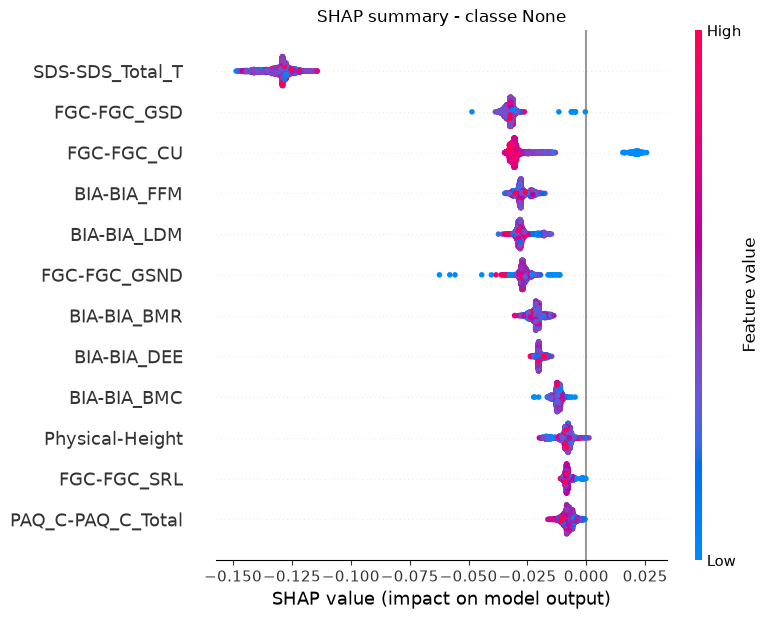

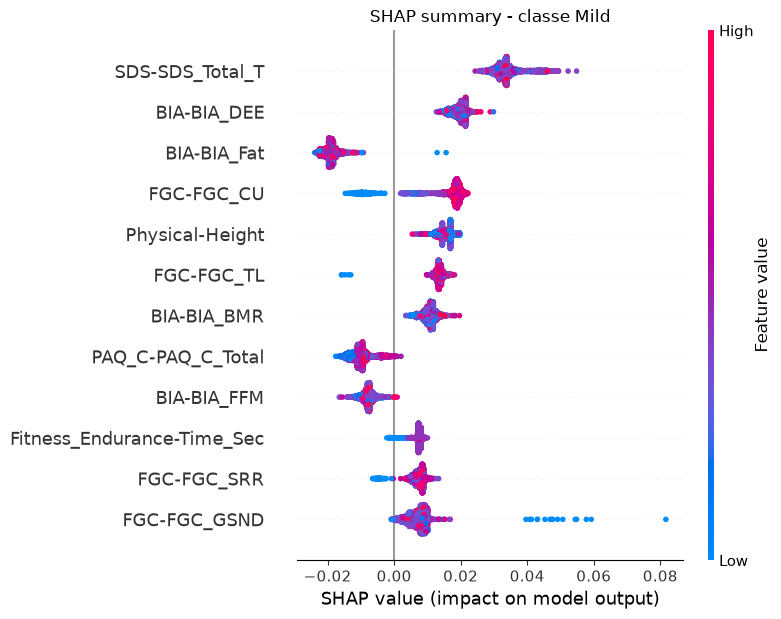

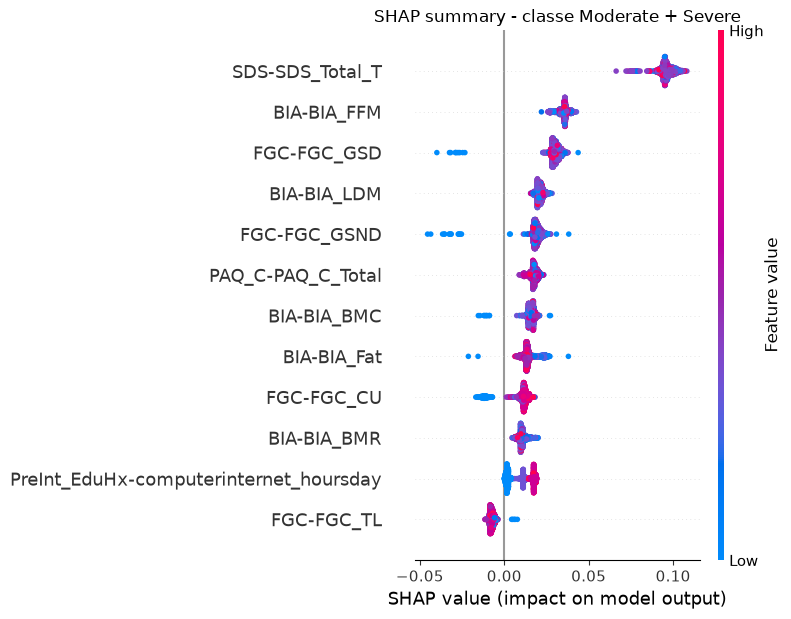

In [13]:
for k, nome in enumerate(CLASSES):
    shap.summary_plot(shap_values[:, :, k], X_test,
                      feature_names=feature_cols, max_display=12, show=False)
    plt.title(f"SHAP summary - classe {nome}")
    plt.tight_layout()
    plt.savefig(f'shap_summary_{nome.replace(" ", "_").replace("+","")}.png', dpi=300, bbox_inches='tight')
    plt.show()

In [14]:
FOCUS, CONFUSED_WITH = 1, 0   # Mild vs None
proba = bb.predict_proba(X_test.values)
pred  = bb.predict(X_test.values)
y_arr = np.array(y_test)
idx_correct = np.where((y_arr == FOCUS) & (pred == FOCUS))[0]
idx_wrong   = np.where((y_arr == FOCUS) & (pred == CONFUSED_WITH))[0]
i_correct = idx_correct[np.argmax(proba[idx_correct, FOCUS])]
i_wrong   = idx_wrong[np.argmax(proba[idx_wrong, CONFUSED_WITH])]
print(f"Corretto  (Mild):   idx={i_correct}  P(Mild)={proba[i_correct, FOCUS]:.2f}")
print(f"Sbagliato (->None): idx={i_wrong}  P(None)={proba[i_wrong, CONFUSED_WITH]:.2f}")

Corretto  (Mild):   idx=453  P(Mild)=0.42
Sbagliato (->None): idx=2372  P(None)=0.37


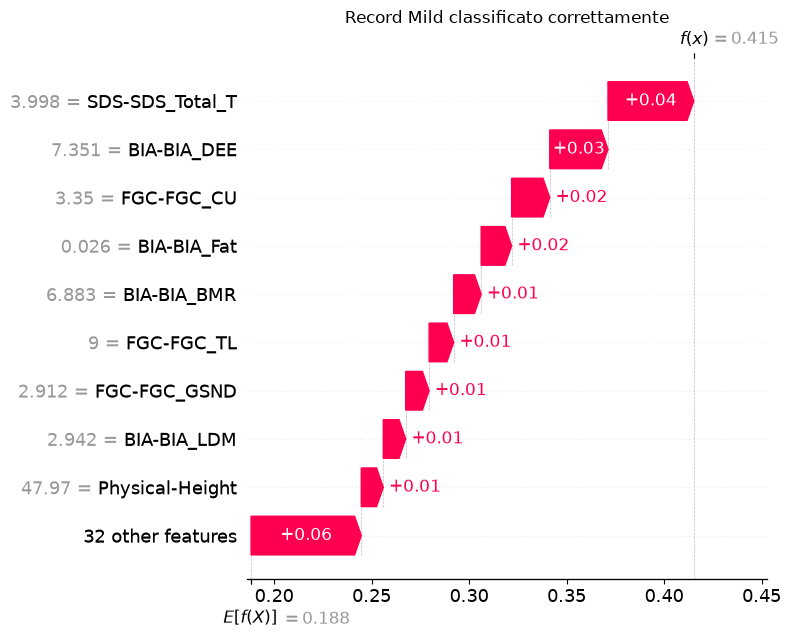

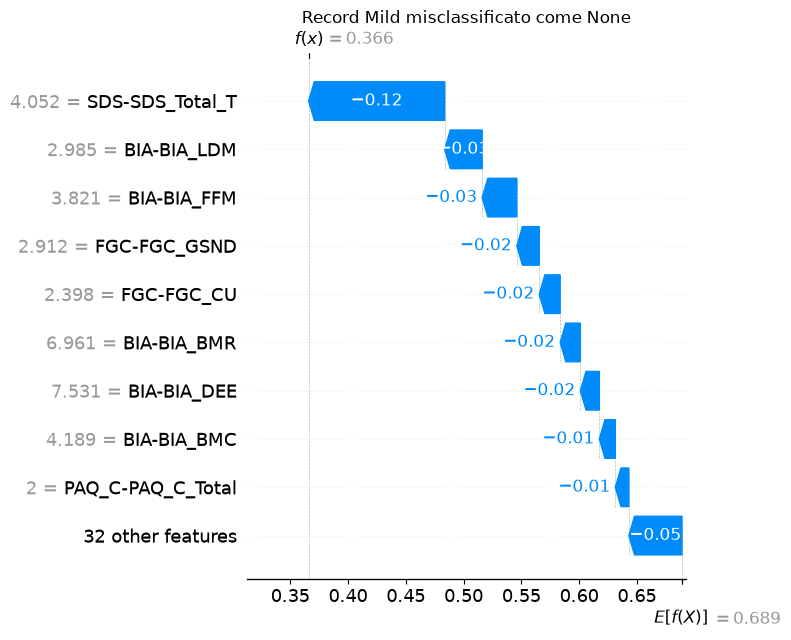

In [15]:
def waterfall(idx, class_idx, titolo, savepath=None):
    exp = shap.Explanation(values=shap_values[idx, :, class_idx],
                           base_values=expected_value[class_idx],
                           data=X_test.values[idx], feature_names=feature_cols)
    shap.plots.waterfall(exp, max_display=10, show=False)
    plt.title(titolo)
    plt.tight_layout()
    if savepath:
        plt.savefig(savepath, dpi=300, bbox_inches='tight')
    plt.show()

waterfall(i_correct, FOCUS, "Record Mild classificato correttamente", "shap_waterfall_correct.png")
waterfall(i_wrong, CONFUSED_WITH, "Record Mild misclassificato come None", "shap_waterfall_wrong.png")

In [23]:
pip install deap


   -------------------- ------------------- 1/2 [deap]
   ---------------------------------------- 2/2 [deap]

Note: you may need to restart the kernel to use updated packages.


In [24]:
import sys
sys.path.append(r'C:\Users\marco\Desktop\DM2\dm2_lab08_xai\lore')

from lorem import LOREM
from util import neuclidean


In [25]:
import sys; sys.path.append('./lore/')          # cartella del corso
from lorem import LOREM
from util import neuclidean

# tutte le feature sono numeriche -> features_map vuoto, numeric = tutte
bb_predict       = lambda Z: bb.predict(Z)
bb_predict_proba = lambda Z: bb.predict_proba(Z)

lore_explainer = LOREM(
    X_train.values,            # K: insieme di riferimento per il vicinato
    bb_predict, feature_cols, 'sii', CLASSES,
    feature_cols,              # numeric_columns: tutte
    {},                        # features_map: nessuna categorica
    neigh_type='geneticp', categorical_use_prob=True,
    continuous_fun_estimation=False, size=1000, ocr=0.1,
    random_state=42, ngen=10, bb_predict_proba=bb_predict_proba, verbose=False)

In [26]:
for nome, idx in [('CORRETTO (Mild)', i_correct), ('SBAGLIATO (->None)', i_wrong)]:
    print(f"\n===== Record {nome}  (idx={idx}) =====")
    exp = lore_explainer.explain_instance(
        X_test.values[idx], samples=300, use_weights=True, metric=neuclidean)
    print("Regola:        ", exp.rule)
    print("Controfattuali:")
    for cf in exp.crules:
        print("   ", cf)


===== Record CORRETTO (Mild)  (idx=453) =====
Regola:         { BIA-BIA_Fat <= 0.84 } --> { sii: Mild }
Controfattuali:
    { BIA-BIA_Fat > 0.84, FGC-FGC_CU > 0.20, BIA-BIA_BMC > 0.30, CGAS-CGAS_Score <= 4.42, FGC-FGC_CU_Zone <= 1.15 } --> { sii: Moderate + Severe }

===== Record SBAGLIATO (->None)  (idx=2372) =====
Regola:         { FGC-FGC_GSD <= 0.28, BIA-BIA_Frame_num <= 2.62, BIA-BIA_DEE > 7.38, BIA-BIA_BMR <= 7.23, FGC-FGC_GSND <= 3.56, FGC-FGC_SRL_Zone > 0.22 } --> { sii: None }
Controfattuali:
    { FGC-FGC_GSD > 0.28, BIA-BIA_BMC > -0.33, FGC-FGC_SRR_Zone <= 1.34, BIA-BIA_Fat > 0.29, PAQ_A-PAQ_A_Total <= 1.24 } --> { sii: Moderate + Severe }
